# CS6140 Machine Learning Final Project
## Group 2: Predict Students' Dropout and Academic Success
**Members:** Xinya Chen, Yi Su, Haoyang Zhang

---
## How to Run

### Requirements
```bash
pip install pandas numpy matplotlib scikit-learn xgboost
```

### Dataset
Dataset is included in the submission. Original source: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)

### Steps
1. Place the dataset CSV file in the same directory as this notebook
2. Update the file path in the data loading cell to match your local path
3. Run all cells in order (**Kernel → Restart & Run All**)

## Notebook Structure
- **Part 1 - Data Preprocessing:** Load dataset, check missing values, encode labels, train/test split, standardization
- **Part 2 - Model Training & Cross-Validation:** Baseline CV, overfitting analysis, hyperparameter tuning, ablation study
- **Part 3 - Evaluation & Analysis:** Final test set evaluation, error analysis, extreme error analysis, feature importance

### Part A: Data Preprocessing

### Load Dataset

In [2]:
import pandas as pd 
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# read the CSV file into a pandas DataFrame
# sep=';' is used to specify that the separator in the CSV file is a semicolon
df = pd.read_csv("predict_students'_dropout_and_academic_success.csv", sep=';')

print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (4424, 37)


### Column Names

In [3]:
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)
print("Columns in the dataset:")
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    print(f"{i:2d}. {col:<50} | {dtype}")

Columns in the dataset:
 1. Marital status                                     | int64
 2. Application mode                                   | int64
 3. Application order                                  | int64
 4. Course                                             | int64
 5. Daytime/evening attendance                         | int64
 6. Previous qualification                             | int64
 7. Previous qualification (grade)                     | float64
 8. Nacionality                                        | int64
 9. Mother's qualification                             | int64
10. Father's qualification                             | int64
11. Mother's occupation                                | int64
12. Father's occupation                                | int64
13. Admission grade                                    | float64
14. Displaced                                          | int64
15. Educational special needs                          | int64
16. Debtor                 

### Missing Values Check

In [4]:
error_num = df.isnull().sum()
print("Missing values: ")
print(error_num)

Missing values: 
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                             

### Targets Distribution

Target,Count,Percentage
Graduate,2209,49.93%
Dropout,1421,32.12%
Enrolled,794,17.95%


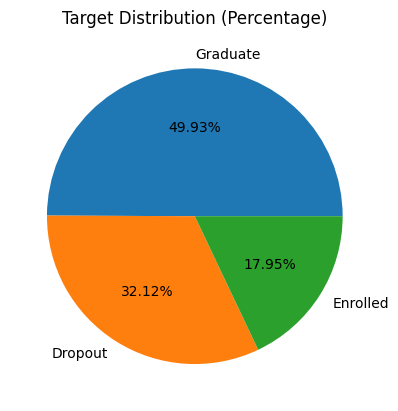

In [5]:
# show the distribution of the target variable in a tabular format
counts = df['Target'].value_counts().reset_index()
counts.columns = ['Target', 'Count']
# add percentage column
counts['Percentage'] = (counts['Count'] / counts['Count'].sum()) * 100
# format percentage to 2 decimal places
counts['Percentage'] = counts['Percentage'].map('{:.2f}%'.format)
display(counts.style.hide(axis="index"))

# show the distribution of the target variable using a pie chart
plt.figure()
counts = df['Target'].value_counts()
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.2f%%'
)
plt.title("Target Distribution (Percentage)")
plt.show()

### Preprocess Dataset

In [6]:
""" LabelEncoder converts categorical labels to numeric labels ->  
sorts categorical labels alphabetically, and assigns integer values starting from 0;
Index = encoded value. """
le = LabelEncoder() 
df["Target"] = le.fit_transform(df["Target"])
mapping = {int(k): v for k, v in zip(le.transform(le.classes_), le.classes_)}
print(f"mapping: {mapping}")


mapping: {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}


### Split Dataset (80% train data + 20% test data)

In [7]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")

X_train.shape: (3539, 36)
y_train.shape: (3539,)


---

## Part B: Model Training & Cross-Validation

In [8]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Define Baseline Models

In [9]:
# linear baseline, nonlinear single tree, ensemble trees, kernel method, boosted trees
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),  # 100 trees (arbitrary)
    "SVM (RBF)": SVC(kernel="rbf", random_state=42),  # radial basis function kernel
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),  # multiclass log loss
}

### 5-Fold Cross-Validation (Baselines)

In [10]:
# stratified keeps class ratios consistent across folds since enrolled is only 18% of the data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

cv_results = []

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)
    cv_results.append({
        "Model": name,
        "Accuracy": str(scores['test_accuracy'].mean()) + " +/- " + str(scores['test_accuracy'].std()),
        "Precision": str(scores['test_precision_macro'].mean()) + " +/- " + str(scores['test_precision_macro'].std()),
        "Recall": str(scores['test_recall_macro'].mean()) + " +/- " + str(scores['test_recall_macro'].std()),
        "F1 macro": str(scores['test_f1_macro'].mean()) + " +/- " + str(scores['test_f1_macro'].std()),
    })
    print("done:", name)

cv_df = pd.DataFrame(cv_results)
display(cv_df)

done: Logistic Regression
done: Decision Tree
done: Random Forest
done: SVM (RBF)
done: XGBoost


,Model,Accuracy,Precision,Recall,F1 macro
0,Logistic Regression,0.7660277771118517 +/- 0.013945299932083736,0.7077469358846932 +/- 0.02818972432588721,0.668110173743903 +/- 0.016200919842094326,0.6755922066839094 +/- 0.019245267733565108
1,Decision Tree,0.6852200353207234 +/- 0.008788432534552788,0.6263734325768703 +/- 0.00716662460804998,0.6273762366162827 +/- 0.009416133143089282,0.6261117170234459 +/- 0.00814953750039827
2,Random Forest,0.7697108814997723 +/- 0.01167806927551851,0.7180216394474386 +/- 0.01889628254362142,0.6781044042531291 +/- 0.020251435473613296,0.6868223145359854 +/- 0.022827055763738637
3,SVM (RBF),0.7584058526918066 +/- 0.007216779171435001,0.7092967089414468 +/- 0.014249355989994153,0.6602316770244908 +/- 0.01036379712644185,0.6710685513996832 +/- 0.012664971998783157
4,XGBoost,0.7730967164513061 +/- 0.011487870923333806,0.7242305883909486 +/- 0.01581018686218277,0.6986903281242995 +/- 0.016344899708948195,0.7071092184068345 +/- 0.01669550413776013


### Overfitting / Underfitting Analysis (Train vs CV Score)

,Model,Train F1,CV F1,Gap,Diagnosis
0,Logistic Regression,0.6913,0.6756,0.0157,Good fit
1,Decision Tree,1.0000,0.6261,0.3739,Overfitting
2,Random Forest,1.0000,0.6868,0.3132,Overfitting
3,SVM (RBF),0.7727,0.6711,0.1016,Overfitting
4,XGBoost,1.0000,0.7071,0.2929,Overfitting


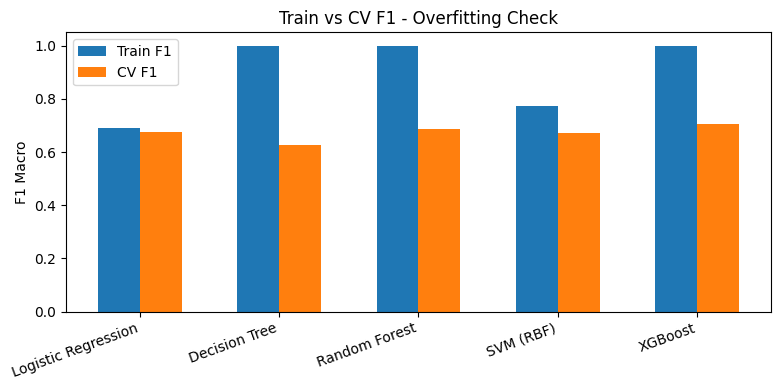

In [11]:
# compare train score vs cv score to detect overfitting or underfitting
overfit_results = []

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring="f1_macro", return_train_score=True)
    train_mean = scores['train_score'].mean()
    test_mean = scores['test_score'].mean()
    gap = train_mean - test_mean
    overfit_results.append({
        "Model": name,
        "Train F1": round(train_mean, 4),
        "CV F1": round(test_mean, 4),
        "Gap": round(gap, 4),
        "Diagnosis": "Overfitting" if gap > 0.05 else ("Underfitting" if test_mean < 0.65 else "Good fit")
    })

overfit_df = pd.DataFrame(overfit_results)
display(overfit_df)

# visualize the gap
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(overfit_df))
ax.bar([i - 0.15 for i in x], overfit_df["Train F1"], width=0.3, label="Train F1")
ax.bar([i + 0.15 for i in x], overfit_df["CV F1"], width=0.3, label="CV F1")
ax.set_xticks(list(x))
ax.set_xticklabels(overfit_df["Model"], rotation=20, ha="right")
ax.set_ylabel("F1 Macro")
ax.set_title("Train vs CV F1 - Overfitting Check")
ax.legend()
plt.tight_layout()
plt.show()

### Hyperparameter Tuning - Logistic Regression

In [12]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],  # smaller C = stronger regularization
    "penalty": ["l1", "l2"],  # l1 can zero out features (absolute), l2 just shrinks them (square)
    "solver": ["saga"], 
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    lr_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,  
    refit=True 
)
lr_grid.fit(X_train, y_train)

print("Best params:", lr_grid.best_params_)
print("Best CV F1:", lr_grid.best_score_)

# show top 5 configs sorted by F1
lr_top5 = (
    pd.DataFrame(lr_grid.cv_results_)
    [["param_C", "param_penalty", "mean_test_score", "std_test_score"]]
    .sort_values("mean_test_score", ascending=False)
    .head(5)
    .reset_index(drop=True)
)
lr_top5.columns = ["C", "Penalty", "Mean F1", "Std F1"]
display(lr_top5)

Best params: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best CV F1: 0.6762159037554972


,C,Penalty,Mean F1,Std F1
0,1.0,l1,0.676216,0.016886
1,1.0,l2,0.675680,0.019243
2,100.0,l2,0.675499,0.016951
3,10.0,l2,0.675499,0.016951
4,10.0,l1,0.675079,0.016477


### Hyperparameter Tuning - SVM (RBF)

In [13]:
svm_param_grid = {
    "C": [0.1, 1, 10, 100],  # tradeoff between margin width and misclassification
    "gamma": ["scale", "auto", 0.01, 0.1],  # high gamma = tighter decision boundary, risk overfitting
}

svm_grid = GridSearchCV(
    SVC(kernel="rbf", random_state=42),
    svm_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True
)
svm_grid.fit(X_train, y_train)

print("Best params:", svm_grid.best_params_)
print("Best CV F1:", svm_grid.best_score_)

svm_top5 = (
    pd.DataFrame(svm_grid.cv_results_)
    [["param_C", "param_gamma", "mean_test_score", "std_test_score"]]
    .sort_values("mean_test_score", ascending=False)
    .head(5)
    .reset_index(drop=True)
)
svm_top5.columns = ["C", "Gamma", "Mean F1", "Std F1"]
display(svm_top5)

Best params: {'C': 10, 'gamma': 0.01}
Best CV F1: 0.6821291320290029


,C,Gamma,Mean F1,Std F1
0,10.0,0.01,0.682129,0.025208
1,10.0,scale,0.674944,0.019151
2,1.0,0.01,0.674700,0.008176
3,10.0,auto,0.673395,0.019705
4,1.0,scale,0.671069,0.012665


### Hyperparameter Tuning - Random Forest

In [14]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],  # number of trees
    "max_depth": [None, 10, 20],  # None = grow until pure leaves
    "min_samples_split": [2, 5],  # min samples to split a node
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True
)
rf_grid.fit(X_train, y_train)

print("Best params:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1: 0.6917209592143162


### Hyperparameter Tuning - XGBoost

In [15]:
xgb_param_grid = {
    "n_estimators": [100, 200],  # boosting rounds
    "max_depth": [3, 5, 7],  # deeper = more complex, risk overfitting
    "learning_rate": [0.01, 0.1, 0.3],  # step size shrinkage
}

xgb_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    xgb_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True
)
xgb_grid.fit(X_train, y_train)

print("Best params:", xgb_grid.best_params_)
print("Best CV F1:", xgb_grid.best_score_)

Best params: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200}
Best CV F1: 0.7092701946590505


### Ablation Study - 10+ Configurations

done: XGB default
done: XGB depth=3
done: XGB depth=7
done: XGB depth=10
done: XGB lr=0.01
done: XGB lr=0.3
done: XGB n_est=50
done: XGB n_est=300
done: LR balanced
done: RF balanced
done: SVM balanced
done: DT balanced


,Config,Train F1,CV F1,Std
0,XGB default,1.0000,0.7071,0.0167
1,XGB lr=0.3,1.0000,0.7071,0.0167
2,XGB depth=3,0.8724,0.7067,0.0068
3,XGB depth=10,1.0000,0.7050,0.0118
4,LR balanced,0.7225,0.7036,0.0116
5,XGB n_est=300,1.0000,0.7014,0.0159
6,XGB depth=7,1.0000,0.7012,0.0172
7,XGB n_est=50,0.9884,0.6971,0.0099
8,SVM balanced,0.7931,0.6938,0.0128
9,RF balanced,1.0000,0.6853,0.0112


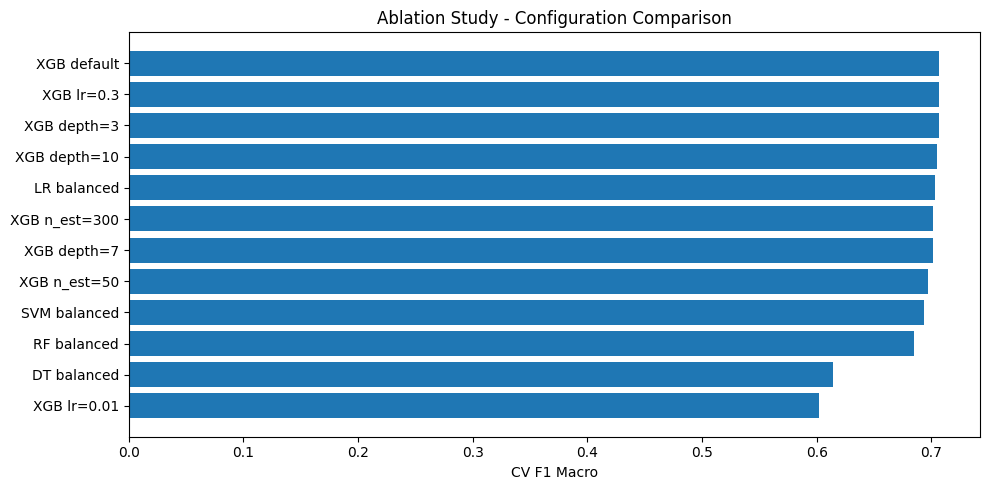

In [16]:
# systematically testing one thing at a time to measure impact
ablation_configs = {
    # baseline
    "XGB default": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),

    # vary max_depth
    "XGB depth=3": XGBClassifier(max_depth=3, use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    "XGB depth=7": XGBClassifier(max_depth=7, use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    "XGB depth=10": XGBClassifier(max_depth=10, use_label_encoder=False, eval_metric="mlogloss", random_state=42),

    # vary learning rate
    "XGB lr=0.01": XGBClassifier(learning_rate=0.01, use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    "XGB lr=0.3": XGBClassifier(learning_rate=0.3, use_label_encoder=False, eval_metric="mlogloss", random_state=42),

    # vary n_estimators
    "XGB n_est=50": XGBClassifier(n_estimators=50, use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    "XGB n_est=300": XGBClassifier(n_estimators=300, use_label_encoder=False, eval_metric="mlogloss", random_state=42),

    # class weight via scale_pos_weight approximation using sample_weight in CV isn't clean,
    # so compare balanced variants of other models instead
    "LR balanced": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "RF balanced": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "SVM balanced": SVC(kernel="rbf", class_weight="balanced", random_state=42),
    "DT balanced": DecisionTreeClassifier(class_weight="balanced", random_state=42),
}

ablation_results = []

for name, model in ablation_configs.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring="f1_macro", return_train_score=True)
    ablation_results.append({
        "Config": name,
        "Train F1": round(scores["train_score"].mean(), 4),
        "CV F1": round(scores["test_score"].mean(), 4),
        "Std": round(scores["test_score"].std(), 4),
    })
    print("done:", name)

ablation_df = pd.DataFrame(ablation_results).sort_values("CV F1", ascending=False).reset_index(drop=True)
display(ablation_df)

# bar chart of ablation results
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(ablation_df["Config"], ablation_df["CV F1"])
ax.set_xlabel("CV F1 Macro")
ax.set_title("Ablation Study - Configuration Comparison")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Final CV Comparison (Tuned Models Swapped In)

In [17]:
# replace all models with their best tuned versions
final_models = {
    "Logistic Regression (tuned)": lr_grid.best_estimator_,
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest (tuned)": rf_grid.best_estimator_,
    "SVM RBF (tuned)": svm_grid.best_estimator_,
    "XGBoost (tuned)": xgb_grid.best_estimator_,
}

final_cv = []
for name, model in final_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)
    final_cv.append({
        "Model": name,
        "Accuracy": str(scores['test_accuracy'].mean()) + " +/- " + str(scores['test_accuracy'].std()),
        "Precision": str(scores['test_precision_macro'].mean()) + " +/- " + str(scores['test_precision_macro'].std()),
        "Recall": str(scores['test_recall_macro'].mean()) + " +/- " + str(scores['test_recall_macro'].std()),
        "F1 macro": str(scores['test_f1_macro'].mean()) + " +/- " + str(scores['test_f1_macro'].std()),
    })

display(pd.DataFrame(final_cv))

,Model,Accuracy,Precision,Recall,F1 macro
0,Logistic Regression (tuned),0.7660289757789339 +/- 0.012013068142844686,0.7074015700658117 +/- 0.023951827198160275,0.668679320932351 +/- 0.014176335655974015,0.6762159037554972 +/- 0.016886497189948408
1,Decision Tree,0.6852200353207234 +/- 0.008788432534552788,0.6263734325768703 +/- 0.00716662460804998,0.6273762366162827 +/- 0.009416133143089282,0.6261117170234459 +/- 0.00814953750039827
2,Random Forest (tuned),0.773945772301201 +/- 0.011226792893375371,0.7292268668684774 +/- 0.017449192750471947,0.6812878690939038 +/- 0.01699758231880543,0.6917209592143162 +/- 0.019454295814926834
3,SVM RBF (tuned),0.761512398213187 +/- 0.016047186998925822,0.7031105345345458 +/- 0.025273791704949897,0.6742710029700398 +/- 0.022340954892097566,0.6821291320290029 +/- 0.025208414753520026
4,XGBoost (tuned),0.7784671445352768 +/- 0.006198275248130911,0.7280285135006905 +/- 0.008616214856626694,0.7002545367175598 +/- 0.009089813387578211,0.7092701946590505 +/- 0.009367120251613117


### Test Set Evaluation

Logistic Regression (tuned)
Accuracy: 0.7694915254237288
F1: 0.68493665228397
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.53      0.34      0.41       159
    Graduate       0.81      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.68       885
weighted avg       0.75      0.77      0.75       885



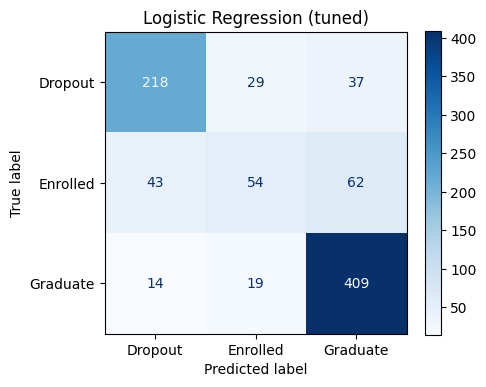


Decision Tree
Accuracy: 0.6949152542372882
F1: 0.636488781621525
              precision    recall  f1-score   support

     Dropout       0.70      0.69      0.70       284
    Enrolled       0.40      0.43      0.41       159
    Graduate       0.81      0.79      0.80       442

    accuracy                           0.69       885
   macro avg       0.64      0.64      0.64       885
weighted avg       0.70      0.69      0.70       885



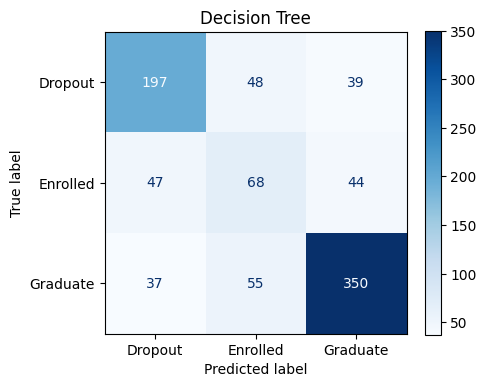


Random Forest (tuned)
Accuracy: 0.7728813559322034
F1: 0.6958706391664761
              precision    recall  f1-score   support

     Dropout       0.82      0.76      0.79       284
    Enrolled       0.57      0.36      0.44       159
    Graduate       0.79      0.93      0.85       442

    accuracy                           0.77       885
   macro avg       0.73      0.68      0.70       885
weighted avg       0.76      0.77      0.76       885



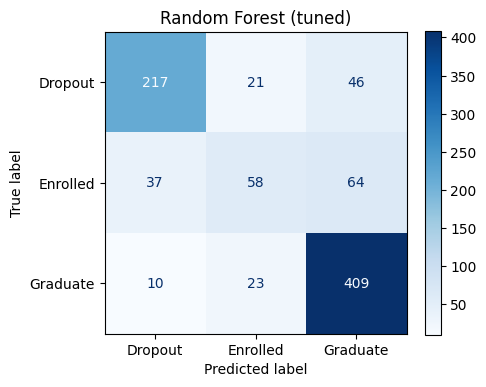


SVM RBF (tuned)
Accuracy: 0.7480225988700565
F1: 0.6746920643508324
              precision    recall  f1-score   support

     Dropout       0.79      0.73      0.76       284
    Enrolled       0.49      0.38      0.43       159
    Graduate       0.79      0.89      0.84       442

    accuracy                           0.75       885
   macro avg       0.69      0.67      0.67       885
weighted avg       0.74      0.75      0.74       885



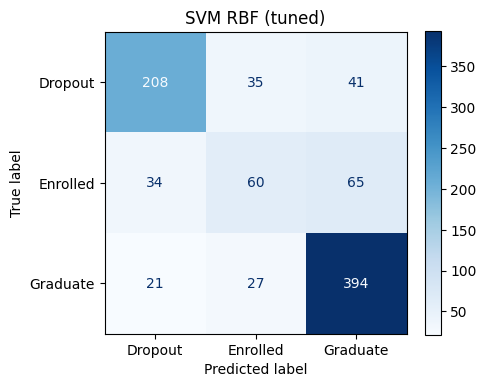


XGBoost (tuned)
Accuracy: 0.7536723163841808
F1: 0.6855579195692746
              precision    recall  f1-score   support

     Dropout       0.80      0.72      0.76       284
    Enrolled       0.49      0.42      0.45       159
    Graduate       0.81      0.89      0.85       442

    accuracy                           0.75       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.75      0.75       885



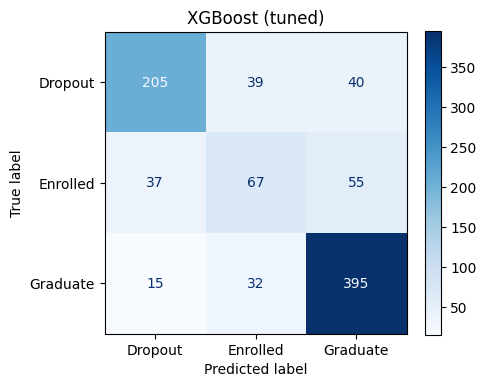

In [18]:
# only touch test set after all model selection is done
for name, model in final_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred, average="macro"))
    print(classification_report(y_test, y_pred, target_names=["Dropout", "Enrolled", "Graduate"])) # per-class breakdown

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Dropout", "Enrolled", "Graduate"],
        cmap="Blues", ax=ax
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()
    print()

### Error Analysis - Examining Misclassified Samples

In [19]:
best_model = xgb_grid.best_estimator_
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

feature_names = df.drop("Target", axis=1).columns.tolist()

# build dataframe of test set with predictions
error_df = pd.DataFrame(X_test, columns=feature_names)
error_df["True Label"] = y_test.values
error_df["Predicted"] = y_pred_best
error_df["Correct"] = error_df["True Label"] == error_df["Predicted"]

# map labels back to names
label_map = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
error_df["True Name"] = error_df["True Label"].map(label_map)
error_df["Pred Name"] = error_df["Predicted"].map(label_map)

total = len(error_df)
misclassified = error_df[~error_df["Correct"]]
print("Total test samples:", total)
print("Misclassified:", len(misclassified))
print("Error rate:", round(len(misclassified) / total, 4))

Total test samples: 885
Misclassified: 218
Error rate: 0.2463


In [20]:
confusion_pairs = misclassified.groupby(["True Name", "Pred Name"]).size().reset_index(name="Count")
confusion_pairs = confusion_pairs.sort_values("Count", ascending=False).reset_index(drop=True)
print("Most common misclassification pairs:")
display(confusion_pairs)

Most common misclassification pairs:


,True Name,Pred Name,Count
0,Enrolled,Graduate,55
1,Dropout,Graduate,40
2,Dropout,Enrolled,39
3,Enrolled,Dropout,37
4,Graduate,Enrolled,32
5,Graduate,Dropout,15


In [21]:
print("Feature comparison: correct vs misclassified Enrolled students")
print("(features shown are scaled values)")
print()

enrolled_correct = error_df[(error_df["True Name"] == "Enrolled") & (error_df["Correct"])]
enrolled_wrong = error_df[(error_df["True Name"] == "Enrolled") & (~error_df["Correct"])]

if len(enrolled_correct) > 0 and len(enrolled_wrong) > 0:
    comparison = pd.DataFrame({
        "Correct (mean)": enrolled_correct[feature_names].mean(),
        "Misclassified (mean)": enrolled_wrong[feature_names].mean(),
        "Difference": enrolled_wrong[feature_names].mean() - enrolled_correct[feature_names].mean()
    })
    comparison = comparison.reindex(comparison["Difference"].abs().sort_values(ascending=False).index)
    display(comparison.head(10))

Feature comparison: correct vs misclassified Enrolled students
(features shown are scaled values)



,Correct (mean),Misclassified (mean),Difference
Unemployment rate,-0.424587,-0.044837,0.379749
Father's occupation,0.179420,-0.091925,-0.271345
Displaced,0.156994,-0.097952,-0.254946
Mother's occupation,0.163265,-0.080442,-0.243707
Curricular units 2nd sem (evaluations),0.509585,0.267153,-0.242431
Curricular units 2nd sem (grade),0.288909,0.053724,-0.235184
Scholarship holder,-0.340926,-0.106078,0.234848
Course,0.067262,-0.151225,-0.218487
Curricular units 2nd sem (without evaluations),0.265358,0.048577,-0.216782
Father's qualification,-0.308329,-0.114076,0.194253


In [22]:
# where do misclassified Enrolled students actually get sent?
print("Enrolled students misclassified as:")
enrolled_errors = misclassified[misclassified["True Name"] == "Enrolled"]
print(enrolled_errors["Pred Name"].value_counts())
print()

print("Dropout students misclassified as:")
dropout_errors = misclassified[misclassified["True Name"] == "Dropout"]
print(dropout_errors["Pred Name"].value_counts())

Enrolled students misclassified as:
Pred Name
Graduate    55
Dropout     37
Name: count, dtype: int64

Dropout students misclassified as:
Pred Name
Graduate    40
Enrolled    39
Name: count, dtype: int64


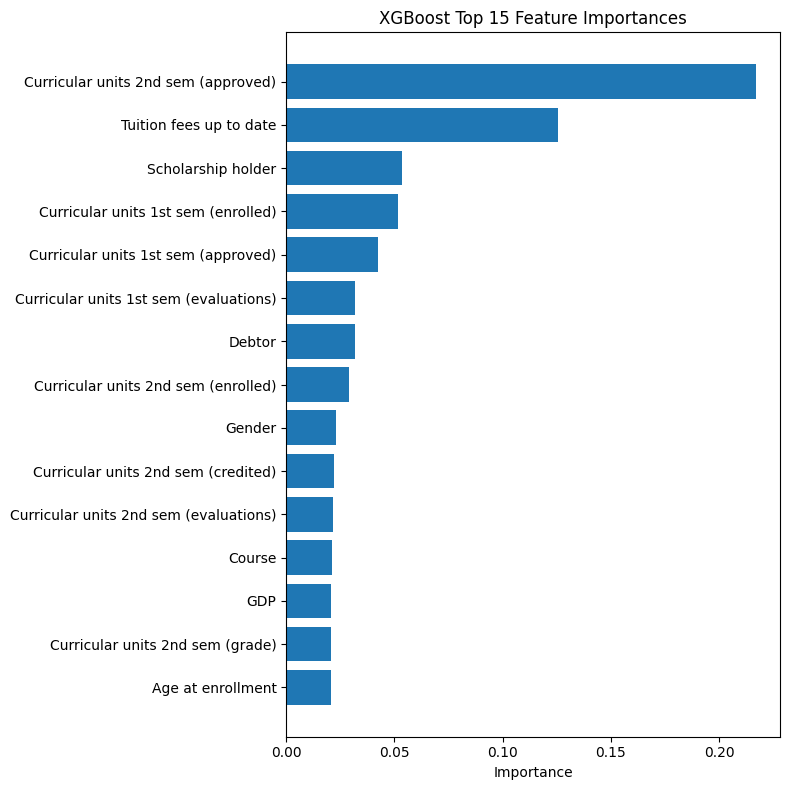

,Feature,Importance
0,Curricular units 2nd sem (approved),0.217337
1,Tuition fees up to date,0.125748
2,Scholarship holder,0.053478
3,Curricular units 1st sem (enrolled),0.051865
4,Curricular units 1st sem (approved),0.042312
5,Curricular units 1st sem (evaluations),0.031879
6,Debtor,0.031764
7,Curricular units 2nd sem (enrolled),0.028968
8,Gender,0.023033
9,Curricular units 2nd sem (credited),0.021931


In [23]:
# feature importance from XGBoost, importance plots, and tabular importance values for top features
importances = best_model.feature_importances_
feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(feat_imp["Feature"][:15], feat_imp["Importance"][:15])
ax.set_xlabel("Importance")
ax.set_title("XGBoost Top 15 Feature Importances")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(feat_imp.head(15))

### Best Hyperparameters Summary

In [24]:
print("Logistic Regression:", lr_grid.best_params_)
print("SVM RBF:", svm_grid.best_params_)
print("Random Forest:", rf_grid.best_params_)
print("XGBoost:", xgb_grid.best_params_)
print("Decision Tree: default params")

Logistic Regression: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
SVM RBF: {'C': 10, 'gamma': 0.01}
Random Forest: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
XGBoost: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200}
Decision Tree: default params


---

## Part C: Evaluation & Analysis

import

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

Final Performance Table

In [26]:
final_test_results = []

# Evaluate each final model on the test set
for name, model in final_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Generate classification report to extract class-specific F1 scores
    report = classification_report(
        y_test,
        y_pred,
        target_names=["Dropout", "Enrolled", "Graduate"],
        output_dict=True,
        zero_division=0
    )

    # Store overall metrics and class-specific F1 scores in the results list
    final_test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 Macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Dropout F1": report["Dropout"]["f1-score"],
        "Enrolled F1": report["Enrolled"]["f1-score"],
        "Graduate F1": report["Graduate"]["f1-score"],
    })

# Create a DataFrame from the results and round the metrics for better readability
final_perf_df = pd.DataFrame(final_test_results).round(4)

metric_cols = [
    "Accuracy", "Precision (macro)", "Recall (macro)", "F1 Macro",
    "Dropout F1", "Enrolled F1", "Graduate F1"
]

# Highlight the best and worst metrics for each column
styled_final_perf_df = (
    final_perf_df.style
    .highlight_max(subset=metric_cols, color="#d9ead3")   
    .highlight_min(subset=metric_cols, color="#f4cccc")   
)

display(styled_final_perf_df)

,Model,Accuracy,Precision (macro),Recall (macro),F1 Macro,Dropout F1,Enrolled F1,Graduate F1
0,Logistic Regression (tuned),0.769500,0.709100,0.677500,0.684900,0.780000,0.413800,0.861100
1,Decision Tree,0.694900,0.635700,0.637700,0.636500,0.697300,0.412100,0.800000
2,Random Forest (tuned),0.772900,0.726200,0.684700,0.695900,0.792000,0.444400,0.851200
3,SVM RBF (tuned),0.748000,0.690200,0.667100,0.674700,0.760500,0.427000,0.836500
4,XGBoost (tuned),0.753700,0.696400,0.679000,0.685600,0.757900,0.451200,0.847600


Extreme Error Analysis - XGBoost vs. Random Forest 

In [27]:
# Analyze misclassifications for the best models
for name in ["XGBoost (tuned)", "Random Forest (tuned)"]:
    model = final_models[name]
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # Create a DataFrame to analyze misclassifications and their confidence scores
    results = pd.DataFrame({
        "true": le.inverse_transform(y_test),
        "pred": le.inverse_transform(y_pred),
        "confidence": y_proba.max(axis=1),
    })
    # Identify misclassifications and those with high confidence
    results["correct"] = results["true"] == results["pred"]
    extreme = results[~results["correct"] & (results["confidence"] > 0.7)]

    # Print summary of misclassifications and extreme cases
    print(f"\n=== {name} ===")
    print(f"Total errors: {(~results['correct']).sum()}")
    print(f"Extreme errors (confidence > 0.7): {len(extreme)}")
    print(extreme.groupby(["true", "pred"]).size().reset_index(name="count").sort_values("count", ascending=False))


=== XGBoost (tuned) ===
Total errors: 218
Extreme errors (confidence > 0.7): 85
       true      pred  count
3  Enrolled  Graduate     21
2  Enrolled   Dropout     21
1   Dropout  Graduate     20
0   Dropout  Enrolled     12
4  Graduate   Dropout      6
5  Graduate  Enrolled      5

=== Random Forest (tuned) ===
Total errors: 201
Extreme errors (confidence > 0.7): 42
       true      pred  count
2  Enrolled  Graduate     20
0   Dropout  Graduate     13
1  Enrolled   Dropout      9


Random Forest - balanced 

In [28]:
# Analyze the impact of class imbalance on Random Forest by using class weights
from sklearn.utils.class_weight import compute_sample_weight
sw = compute_sample_weight("balanced", y_train)

# Train a Random Forest with class weights to see if it reduces extreme misclassifications
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_balanced.fit(X_train, y_train)

# Evaluate the balanced Random Forest
y_pred_rf = rf_balanced.predict(X_test)
y_proba_rf = rf_balanced.predict_proba(X_test)

# Create a DataFrame to analyze misclassifications and their confidence scores for the balanced Random Forest
results_rf = pd.DataFrame({
    "true": le.inverse_transform(y_test),
    "pred": le.inverse_transform(y_pred_rf),
    "confidence": y_proba_rf.max(axis=1),
})
# Identify misclassifications and those with high confidence for the balanced Random Forest
results_rf["correct"] = results_rf["true"] == results_rf["pred"]
# Analyze extreme misclassifications for the balanced Random Forest
extreme_rf = results_rf[~results_rf["correct"] & (results_rf["confidence"] > 0.7)]

print(f"\n=== Random Forest (Balanced) ===")
print(f"Total errors: {(~results_rf['correct']).sum()}")
print(f"Extreme errors (confidence > 0.7): {len(extreme_rf)}")
print(extreme_rf.groupby(["true", "pred"]).size().reset_index(name="count").sort_values("count", ascending=False))


=== Random Forest (Balanced) ===
Total errors: 197
Extreme errors (confidence > 0.7): 41
       true      pred  count
2  Enrolled  Graduate     19
0   Dropout  Graduate     13
1  Enrolled   Dropout      9
